FACE DETECTION SYSTEM - VIOLA-JONES


Saving imagevi.jpg to imagevi.jpg


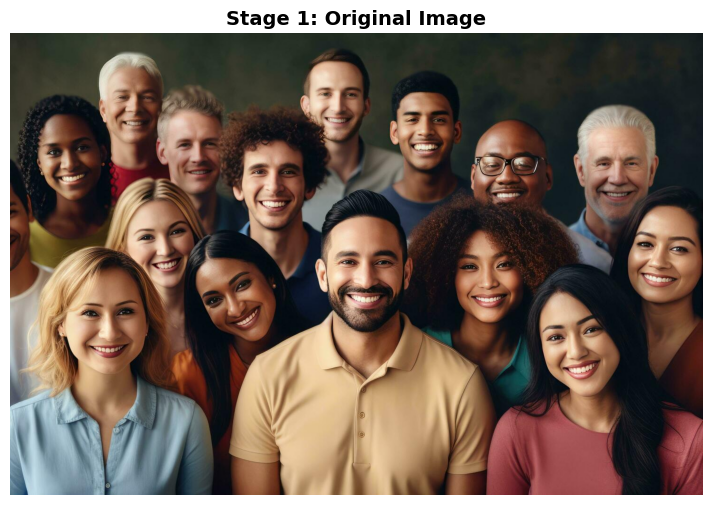

Height: 980 px
Width: 1470 px
Channels: 3 (BGR)


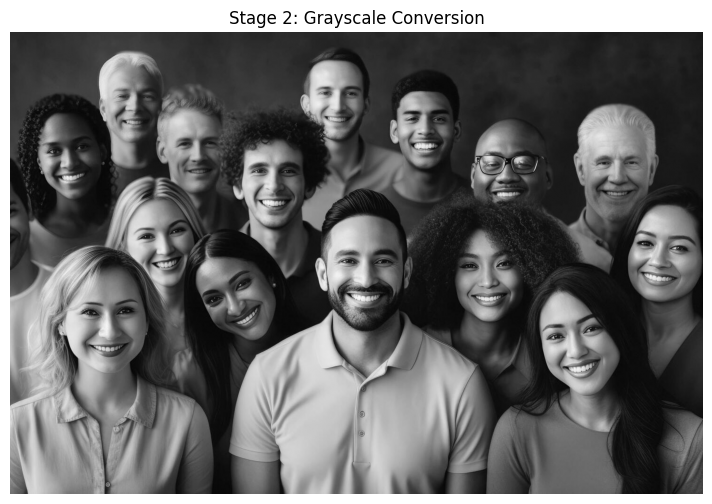

Min: 0, Max: 253
Mean: 86.03, Std: 62.47


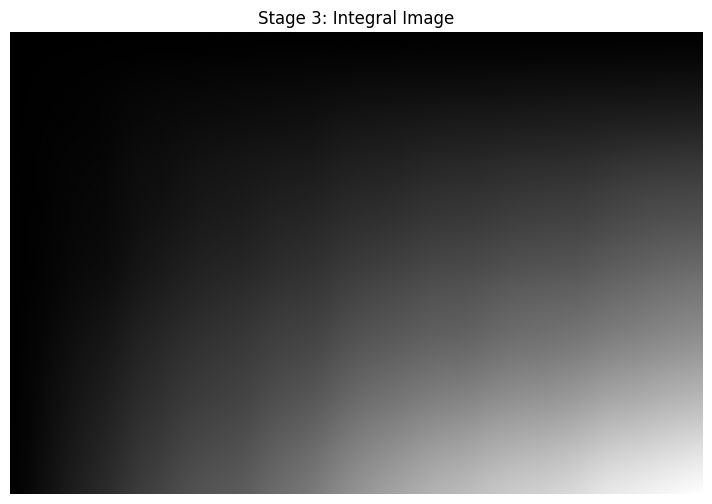

Integral shape: (981, 1471)
Total sum: 123927852


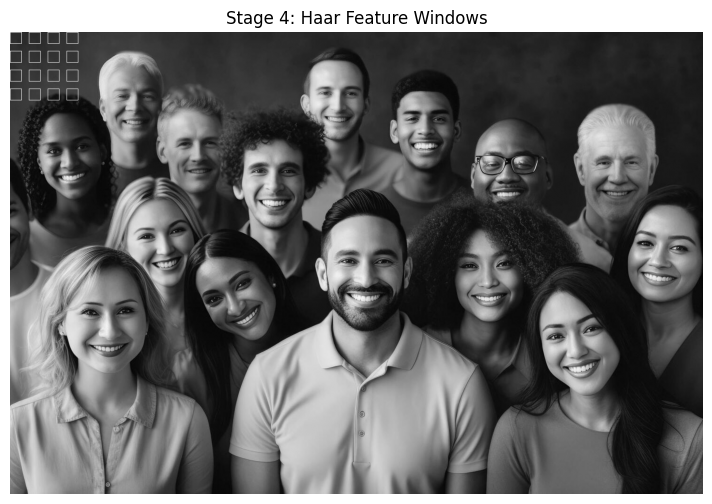

Window size: 24x24
Total features: 16


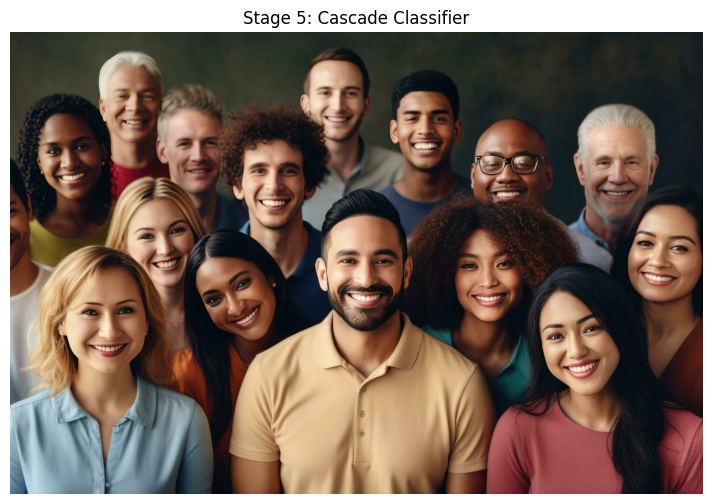

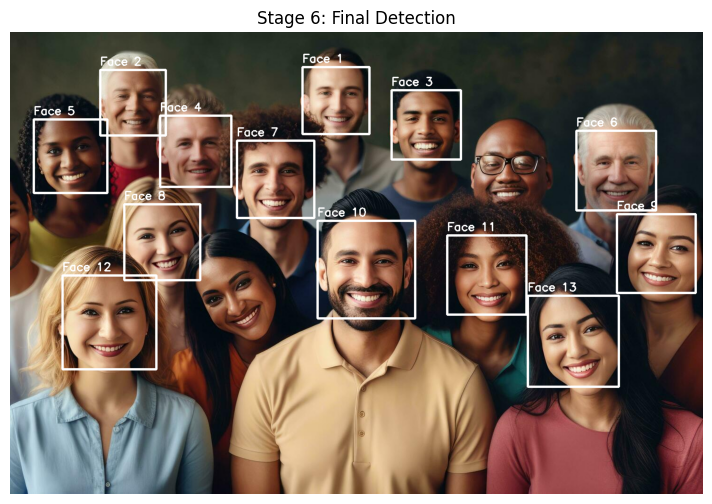

Total faces detected: 13


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

print("=" * 60)
print("FACE DETECTION SYSTEM - VIOLA-JONES")
print("=" * 60)

# -----------------------------
# IMAGE INPUT
# -----------------------------
image_path = None

try:
    from google.colab import files
    uploaded = files.upload()
    if uploaded:
        image_path = list(uploaded.keys())[0]
except:
    image_path = input("Enter image path (or press Enter for demo): ").strip()

# Load image
if image_path and os.path.exists(image_path):
    img = cv2.imread(image_path)
else:
    # Demo image (3 circle faces)
    img = np.ones((400, 600, 3), dtype=np.uint8) * 200
    cv2.circle(img, (150, 200), 60, (100, 150, 200), -1)
    cv2.circle(img, (450, 200), 60, (100, 150, 200), -1)
    cv2.circle(img, (300, 350), 60, (100, 150, 200), -1)

# -----------------------------
# STAGE 1: ORIGINAL IMAGE
# -----------------------------
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Stage 1: Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

print(f"Height: {img.shape[0]} px")
print(f"Width: {img.shape[1]} px")
print(f"Channels: {img.shape[2]} (BGR)")

# -----------------------------
# STAGE 2: GRAYSCALE
# -----------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 6))
plt.imshow(gray, cmap='gray')
plt.title('Stage 2: Grayscale Conversion')
plt.axis('off')
plt.show()

print(f"Min: {gray.min()}, Max: {gray.max()}")
print(f"Mean: {gray.mean():.2f}, Std: {gray.std():.2f}")

# -----------------------------
# STAGE 3: INTEGRAL IMAGE
# -----------------------------
integral = cv2.integral(gray)

integral_norm = cv2.normalize(integral, None, 0, 255, cv2.NORM_MINMAX)
integral_norm = integral_norm.astype(np.uint8)

plt.figure(figsize=(10, 6))
plt.imshow(integral_norm, cmap='gray')
plt.title('Stage 3: Integral Image')
plt.axis('off')
plt.show()

print(f"Integral shape: {integral.shape}")
print(f"Total sum: {integral[-1, -1]}")

# -----------------------------
# STAGE 4: HAAR FEATURES
# -----------------------------
h, w = gray.shape
win_h, win_w = 24, 24

haar_img = gray.copy()
feature_count = 0

for y in range(0, min(h - win_h, 150), 40):
    for x in range(0, min(w - win_w, 150), 40):
        cv2.rectangle(haar_img, (x, y), (x + win_w, y + win_h), 255, 1)
        feature_count += 1

plt.figure(figsize=(10, 6))
plt.imshow(haar_img, cmap='gray')
plt.title('Stage 4: Haar Feature Windows')
plt.axis('off')
plt.show()

print(f"Window size: {win_w}x{win_h}")
print(f"Total features: {feature_count}")

# -----------------------------
# STAGE 5: CASCADE CLASSIFIER
# -----------------------------
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Stage 5: Cascade Classifier')
plt.axis('off')
plt.show()

# -----------------------------
# STAGE 6: FACE DETECTION
# -----------------------------
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30),
    maxSize=(300, 300)
)

result = img.copy()

for i, (x, y, w, h) in enumerate(faces):
    cv2.rectangle(result, (x, y), (x + w, y + h), (255, 255, 255), 3)
    cv2.putText(result, f"Face {i+1}", (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Stage 6: Final Detection')
plt.axis('off')
plt.show()

print(f"Total faces detected: {len(faces)}")